# Lab 5: Segmentation and Clustering

**Signal, Image and Video Processing** — Dr. Elitza Maneva — 2025–2026

*Notebook prepared with the assistance of Claude (Anthropic)*

### What we'll do

| Part | Topic | Level |
|------|-------|-------|
| 1 | Change point detection in 1D — segmentation before images | 🟢 Basic |
| 2 | Otsu's method and counting objects | 🟢 Basic |
| 3 | K-means segmentation on colour (and spatial) features | 🟡 Intermediate |
| 4 | Watershed transform — separating touching objects | 🟡 Intermediate |

**Required files:** `peppers.png` and `touching_coins.jpg` in the same directory.

In [3]:
# Run this cell first to load all libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from skimage import data, filters, measure, color, segmentation, morphology
from skimage.feature import peak_local_max
from sklearn.cluster import KMeans
from scipy import ndimage

%matplotlib inline

plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

# Load images
img_pepper = cv2.cvtColor(cv2.imread('peppers.png'), cv2.COLOR_BGR2RGB)
img_touching = cv2.cvtColor(cv2.imread('touching_coins.jpg'), cv2.COLOR_BGR2RGB)
print(f'peppers.png:        {img_pepper.shape}')
print(f'touching_coins.jpg: {img_touching.shape}')

peppers.png:        (374, 499, 3)
touching_coins.jpg: (312, 252, 3)


---
## Part 1: Change Point Detection in 1D 🟢

Before we segment images, let's segment a 1D signal. We generate a time series with regime changes and find where the shifts happen by minimising within-segment variance.

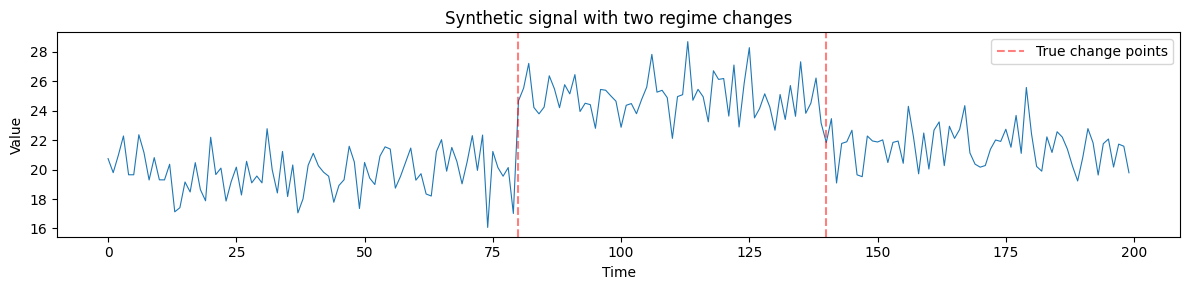

In [4]:
# Generate a synthetic signal with two regime changes
np.random.seed(42)
n1, n2, n3 = 80, 60, 60
seg1 = np.random.normal(loc=20.0, scale=1.5, size=n1)
seg2 = np.random.normal(loc=25.0, scale=1.5, size=n2)
seg3 = np.random.normal(loc=21.5, scale=1.5, size=n3)
signal = np.concatenate([seg1, seg2, seg3])
N = len(signal)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(signal, linewidth=0.8)
ax.axvline(n1, color='red', linestyle='--', alpha=0.5, label='True change points')
ax.axvline(n1 + n2, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Time'); ax.set_ylabel('Value')
ax.set_title('Synthetic signal with two regime changes')
ax.legend()
plt.tight_layout(); plt.show()

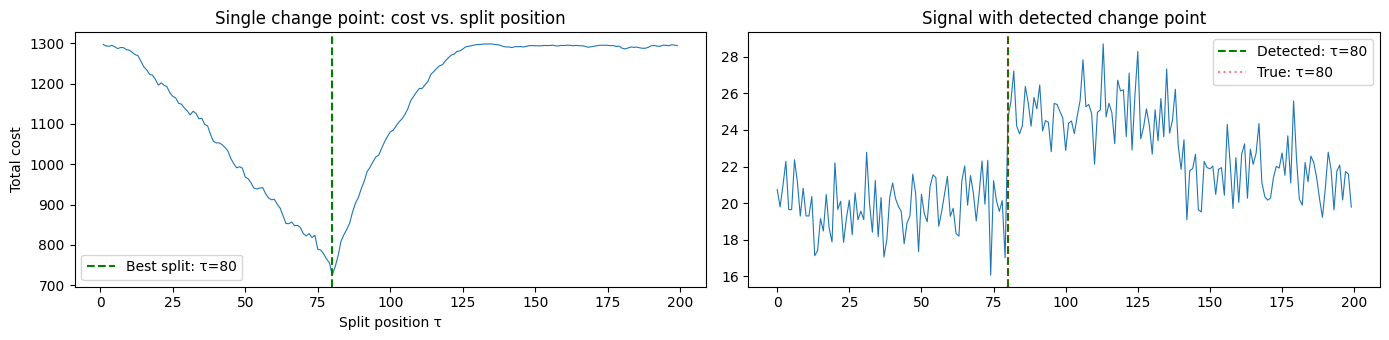

In [5]:
# Cost function: within-segment variance
def segment_cost(x):
    if len(x) == 0: return 0.0
    return np.sum((x - np.mean(x)) ** 2)

# Find the best single change point by brute force
costs_1cp = np.array([segment_cost(signal[:t]) + segment_cost(signal[t:]) for t in range(1, N)])
best_tau = np.argmin(costs_1cp) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
axes[0].plot(range(1, N), costs_1cp, linewidth=0.8)
axes[0].axvline(best_tau, color='green', ls='--', label=f'Best split: τ={best_tau}')
axes[0].set_xlabel('Split position τ'); axes[0].set_ylabel('Total cost')
axes[0].set_title('Single change point: cost vs. split position'); axes[0].legend()

axes[1].plot(signal, linewidth=0.8)
axes[1].axvline(best_tau, color='green', ls='--', label=f'Detected: τ={best_tau}')
axes[1].axvline(n1, color='red', ls=':', alpha=0.5, label=f'True: τ={n1}')
axes[1].set_title('Signal with detected change point'); axes[1].legend()
plt.tight_layout(); plt.show()

Detected: τ1=80, τ2=139
True:     τ1=80, τ2=140


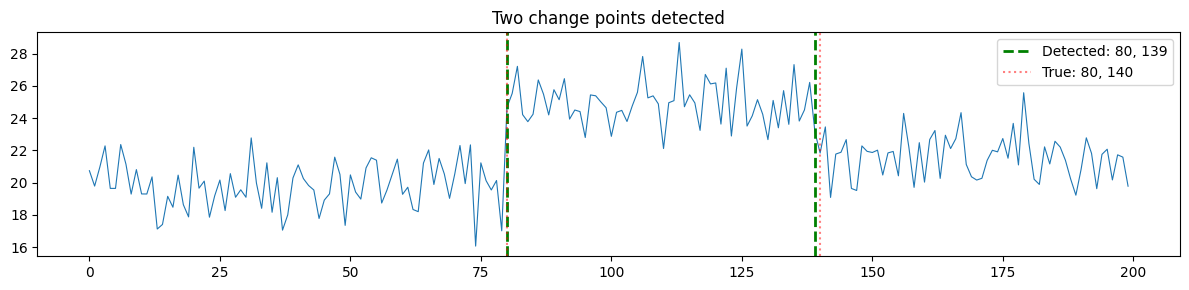

In [6]:
# Two change points: brute-force O(N^2)
best_cost = np.inf
best_t1, best_t2 = 0, 0
for t1 in range(1, N - 1):
    for t2 in range(t1 + 1, N):
        cost = segment_cost(signal[:t1]) + segment_cost(signal[t1:t2]) + segment_cost(signal[t2:])
        if cost < best_cost:
            best_cost = cost
            best_t1, best_t2 = t1, t2

print(f'Detected: τ1={best_t1}, τ2={best_t2}')
print(f'True:     τ1={n1}, τ2={n1+n2}')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(signal, linewidth=0.8)
ax.axvline(best_t1, color='green', ls='--', lw=2, label=f'Detected: {best_t1}, {best_t2}')
ax.axvline(best_t2, color='green', ls='--', lw=2)
ax.axvline(n1, color='red', ls=':', alpha=0.5, label=f'True: {n1}, {n1+n2}')
ax.axvline(n1 + n2, color='red', ls=':', alpha=0.5)
ax.legend(); ax.set_title('Two change points detected')
plt.tight_layout(); plt.show()

🧪 **Experiment:**
- Change the noise level (`scale=1.5`) to `scale=3.0`. How does this affect detection accuracy?
- What happens if the two regimes have the same mean but different variance?
- Try with only one true change point. Does the two-change-point search still give a sensible result?

---
## Part 2: Otsu's Method and Counting Objects 🟢

Otsu applies the same principle to the intensity histogram. Then we use connected component labelling to count objects.

Our Otsu threshold: 108
skimage threshold:  107


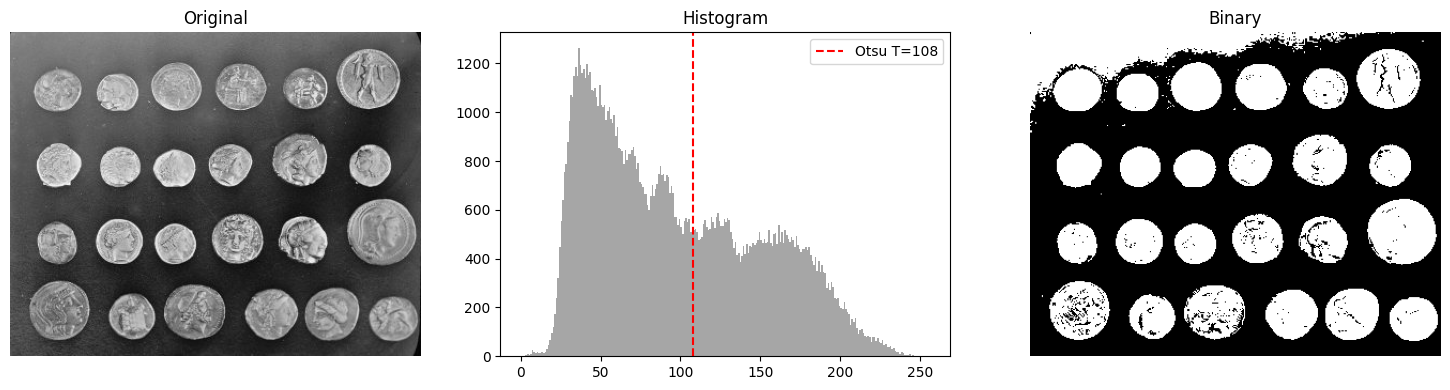

In [7]:
img_coins = data.coins()

# Implement Otsu manually: between-class variance for each threshold
hist, _ = np.histogram(img_coins.ravel(), bins=256, range=(0, 256))
hist_norm = hist / hist.sum()

sigma_b = np.zeros(256)
for T in range(1, 255):
    w0 = hist_norm[:T].sum()
    w1 = hist_norm[T:].sum()
    if w0 == 0 or w1 == 0: continue
    mu0 = np.sum(np.arange(T) * hist_norm[:T]) / w0
    mu1 = np.sum(np.arange(T, 256) * hist_norm[T:]) / w1
    sigma_b[T] = w0 * w1 * (mu0 - mu1) ** 2

otsu_T = np.argmax(sigma_b)
print(f'Our Otsu threshold: {otsu_T}')
print(f'skimage threshold:  {filters.threshold_otsu(img_coins)}')

binary = img_coins > otsu_T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_coins, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].hist(img_coins.ravel(), bins=256, range=(0,256), color='gray', alpha=0.7)
axes[1].axvline(otsu_T, color='red', ls='--', label=f'Otsu T={otsu_T}'); axes[1].legend()
axes[1].set_title('Histogram')
axes[2].imshow(binary, cmap='gray'); axes[2].set_title('Binary'); axes[2].axis('off')
plt.tight_layout(); plt.show()

### Counting objects with connected components

Total components: 88
Components with area > 500: 24


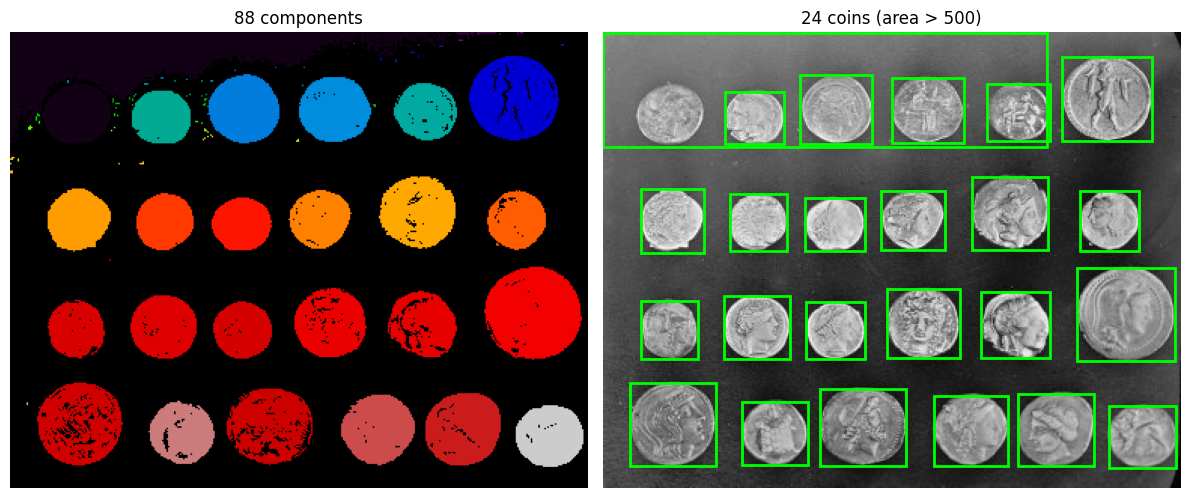

In [8]:
# Label connected components
labels = measure.label(binary)
props = measure.regionprops(labels)

print(f'Total components: {labels.max()}')
print(f'Components with area > 500: {sum(1 for p in props if p.area > 500)}')

# Visualise with bounding boxes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(labels, cmap='nipy_spectral'); axes[0].set_title(f'{labels.max()} components'); axes[0].axis('off')

axes[1].imshow(img_coins, cmap='gray')
coin_count = 0
for p in props:
    if p.area < 500: continue
    coin_count += 1
    minr, minc, maxr, maxc = p.bbox
    rect = mpatches.Rectangle((minc, minr), maxc-minc, maxr-minr,
                               edgecolor='lime', facecolor='none', lw=2)
    axes[1].add_patch(rect)
axes[1].set_title(f'{coin_count} coins (area > 500)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

🧪 **Experiment:**
- Try `classes=3` and `classes=4` with `filters.threshold_multiotsu`. At what point does adding more classes stop being useful?
- Add uneven illumination: `img + np.linspace(0, 80, img.shape[1])`. Does global Otsu still work? Try `filters.threshold_local(img, block_size=51)` instead.

---
## Part 3: K-Means Segmentation 🟡

Otsu works on intensity alone. K-means lets us segment in colour space.

C:\Users\1721251\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\1721251\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


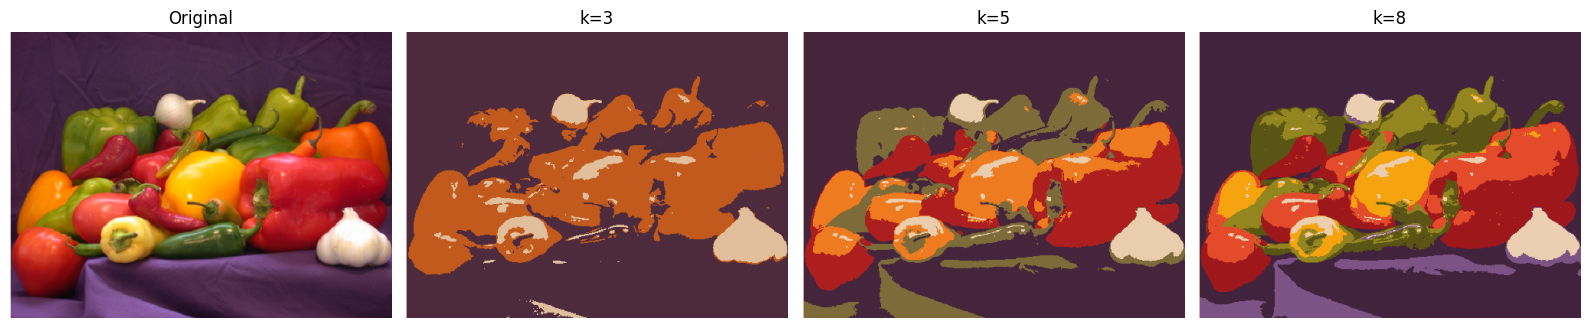

In [9]:
img = img_pepper
H, W, C = img.shape
pixels_rgb = img.reshape(-1, 3).astype(np.float64)

# K-means with different k values
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')

for i, k in enumerate([3, 5, 8]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pixels_rgb)
    seg = km.cluster_centers_[labels].reshape(H, W, 3).astype(np.uint8)
    axes[i+1].imshow(seg); axes[i+1].set_title(f'k={k}'); axes[i+1].axis('off')

plt.tight_layout(); plt.show()

### Adding spatial information

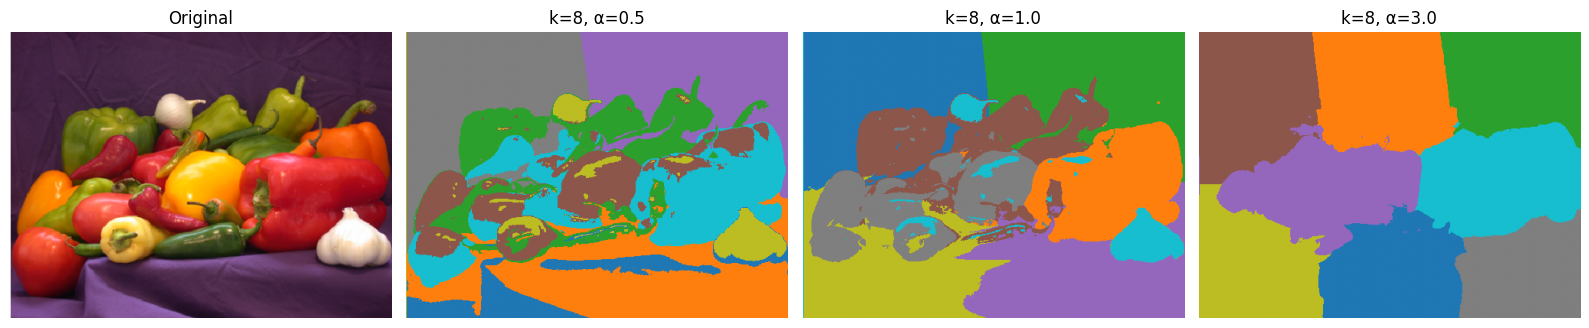

In [10]:
# Build (R, G, B, x, y) features
rows, cols = np.mgrid[0:H, 0:W]
coords = np.stack([rows.ravel(), cols.ravel()], axis=1).astype(np.float64)
pixels_norm = pixels_rgb / 255.0
coords_norm = coords / np.array([H, W])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')

for i, alpha in enumerate([0.5, 1.0, 3.0]):
    features = np.hstack([pixels_norm, alpha * coords_norm])
    km = KMeans(n_clusters=8, random_state=42, n_init=10)
    labels = km.fit_predict(features)
    axes[i+1].imshow(labels.reshape(H, W), cmap='tab10')
    axes[i+1].set_title(f'k=8, α={alpha}'); axes[i+1].axis('off')

plt.tight_layout(); plt.show()

Small α → colour dominates (spatially scattered segments). Large α → position dominates (compact tiles).

🧪 **Experiment:**
- Try `alpha=0` (pure colour) and `alpha=10` (almost pure position). What do the extremes look like?
- Run k-means multiple times with different `random_state`. How stable are the results?
- Plot the within-cluster variance (inertia) vs k for k=2,...,15. Is there an "elbow"?

---
## Part 4: Watershed Transform 🟡

When objects touch, connected components merges them into one blob. The watershed transform uses the distance transform to find separate peaks and split them apart.

### The problem: touching coins

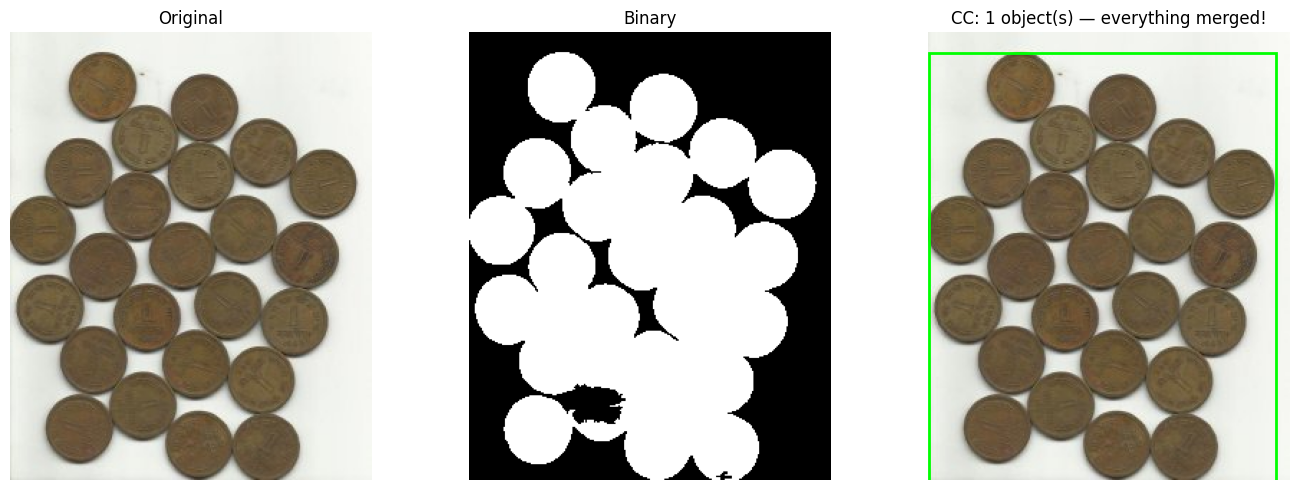

In [11]:
img_tc_gray = cv2.cvtColor(img_touching, cv2.COLOR_RGB2GRAY)

# Adaptive threshold (coins are darker than background)
binary_tc = cv2.adaptiveThreshold(img_tc_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 10) > 0
binary_tc = morphology.remove_small_objects(binary_tc, min_size=100)
binary_tc = ndimage.binary_fill_holes(binary_tc)

labels_cc = measure.label(binary_tc)
props_cc = [p for p in measure.regionprops(labels_cc) if p.area > 300]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_touching); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(binary_tc, cmap='gray'); axes[1].set_title('Binary'); axes[1].axis('off')
axes[2].imshow(img_touching)
for p in props_cc:
    minr, minc, maxr, maxc = p.bbox
    rect = mpatches.Rectangle((minc, minr), maxc-minc, maxr-minr,
                               edgecolor='lime', facecolor='none', lw=2)
    axes[2].add_patch(rect)
axes[2].set_title(f'CC: {len(props_cc)} object(s) — everything merged!')
axes[2].axis('off')
plt.tight_layout(); plt.show()

### The solution: distance transform + watershed

Markers: 19, Watershed regions: 19


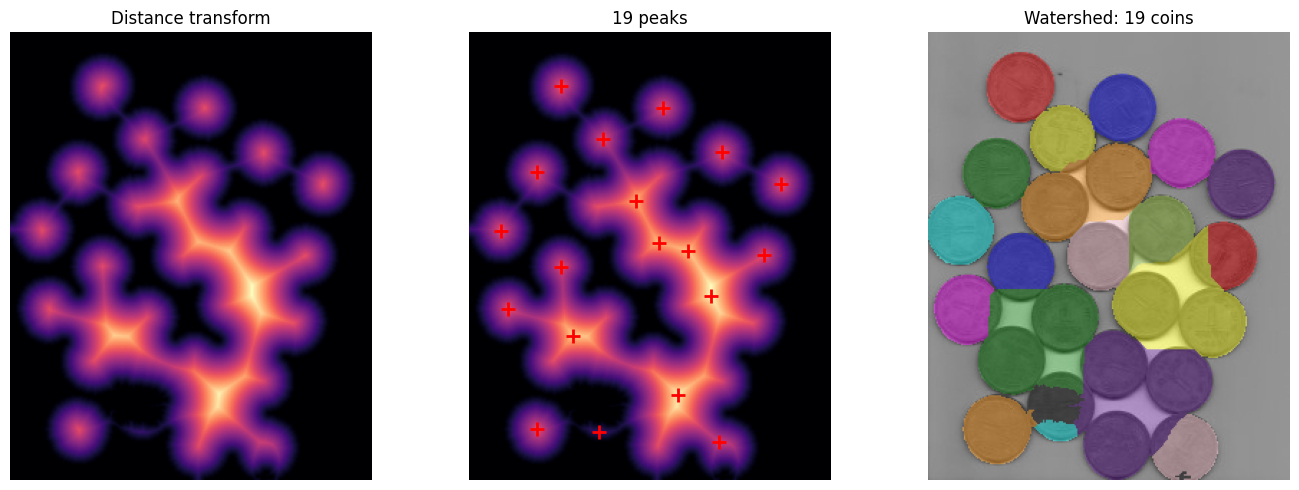

In [12]:
# Distance transform: value = distance to nearest background pixel
distance = ndimage.distance_transform_edt(binary_tc)

# Find peaks — one per object
local_max = peak_local_max(distance, min_distance=10, labels=binary_tc)

# Create markers
markers = np.zeros_like(binary_tc, dtype=int)
for i, (r, c) in enumerate(local_max, start=1):
    markers[r, c] = i
markers = ndimage.label(morphology.dilation(
    markers > 0, morphology.disk(2)) * binary_tc)[0]

# Watershed
labels_ws = segmentation.watershed(-distance, markers, mask=binary_tc)
print(f'Markers: {markers.max()}, Watershed regions: {labels_ws.max()}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(distance, cmap='magma'); axes[0].set_title('Distance transform'); axes[0].axis('off')
axes[1].imshow(distance, cmap='magma')
axes[1].plot(local_max[:, 1], local_max[:, 0], 'r+', markersize=10, markeredgewidth=2)
axes[1].set_title(f'{len(local_max)} peaks'); axes[1].axis('off')
axes[2].imshow(color.label2rgb(labels_ws, img_touching, bg_label=0, alpha=0.4))
axes[2].set_title(f'Watershed: {labels_ws.max()} coins'); axes[2].axis('off')
plt.tight_layout(); plt.show()

🧪 **Experiment:**
- Change `min_distance` to 5, 15, 20, 25. How does the count change?
- Try global Otsu instead of adaptive thresholding. What goes wrong?
- Apply watershed to `skimage.data.coins()` (where objects don't touch). Does it give the same count as connected components?

---
## Summary

| Method | Input | Key parameter | Strengths | Weaknesses |
|--------|-------|---------------|-----------|------------|
| Change point detection | 1D signal | Number of change points | Exact solution, connects to Otsu | 1D only |
| Otsu + CC | Intensity histogram | None (automatic) | Simple, counts objects | Global, intensity only |
| K-means | (R,G,B) or (R,G,B,x,y) | k, spatial weight α | Flexible features | Need to choose k |
| Watershed | Distance transform | min_distance | Separates touching objects | Needs clean binary input |